# Computer Exercise 15.21 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.21 Trunk-level Regularization · 6-condition Ablation
> **풀이 일자**: Day 88


## 1. 문제 (원문)

> **2.** Introduce two **trunk-level regularizers** — (a) inverted dropout on trunk hidden units,
> (b) running-statistics feature whitening — as a third prescription $R$ atop Day 86 의
> $\{+C, +N\}$. Build a 6-condition ablation
> {baseline, +C, +N, +CN, +CNR_drop, +CNR_white}, run 5 seeds × 10 episodes on the reduced
> tail-return model inherited from Day 87 P3, and compute bootstrap 4000× 95% CI for
> **synergy** $\Delta_{sy} = (+CNR) - (+C + +N - \text{baseline})$. Does R flip the sign?

### 한국어 풀이용 정리

Day 87 P3 의 unified-head 시너지는 $-34.24$ (CI $[-41.4, -26.6]$) 로 부호 반전 실패. Day 87 는 twin
처방으로 크기를 27% 완화했으나 여전히 유의 음수. 본 문제는 head 구조 대신 **trunk 활성화에 직접
개입**하는 두 처방 (dropout, whitening) 을 도입해 6-조건 ablation 을 돌리고, 시너지 크기·부호를
부트스트랩 CI 로 판정.


## 2. 수학적 배경

### 2.1 Trunk Inverted Dropout

$$ \tilde h = \frac{m \odot h}{1-p}, \qquad m_j \sim \text{Bern}(1-p). $$

Test 시 mask 없이 사용. Head 파라미터의 co-adaptation 을 줄여 tail estimate 분산을 낮춘다.

### 2.2 Running-statistics Feature Whitening

각 hidden 유닛의 running mean/var $(\hat\mu_j, \hat\sigma_j^2)$ 을 EMA 로 유지:

$$ \tilde h_j = \frac{h_j - \hat\mu_j}{\sqrt{\hat\sigma_j^2 + \varepsilon}}. $$

Feature scale drift 를 억제해 head gradient step 이 안정.

### 2.3 축약 시뮬레이션 모델

Day 84–87 방침 계승. 각 조건 tail-return 을 $\mathcal{N}(\mu_c, \sigma_c^2)$ 로 5 시드 × 10 에피소드
(총 50 표본/조건) 표본화. R 처방 파라미터는 (a) drop: sigma 축소 20%, mu 개선 소폭, (b) white: mu 개선
더 크고 sigma 축소 소폭.

### 2.4 시너지 · 부트스트랩 CI

$$ \Delta_{sy}^{R} = (+CNR) - [(+C) + (+N) - \text{baseline}]. $$

부트스트랩 4000 회, 각 회 50 표본 with replacement, 조건별 mean 재계산 → 2.5%/97.5% quantile CI.


## 3. 풀이 흐름

1. 조건별 $(\mu, \sigma)$ 딕셔너리 정의.
2. 5 시드 × 10 에피소드 표본 생성.
3. 조건별 mean, std 리포트.
4. 시너지 부트스트랩 4000 회 × 3 처방 (unified / +R_drop / +R_white).
5. 시너지 CI 시각화.
6. 결과 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

COND = {
    "baseline":         (-51.7, 12.0),
    "+C":               (-33.2, 10.5),
    "+N":               (-27.4,  9.8),
    "+CN":              (-43.2, 11.2),
    "+CNR_drop":        (-34.5,  8.6),
    "+CNR_white":       (-30.1,  9.3),
}

rng = np.random.default_rng(88301)
N_SEEDS = 5; N_EPS = 10

samples = {name: rng.normal(mu, sd, size=N_SEEDS * N_EPS)
           for name, (mu, sd) in COND.items()}

summary = pd.DataFrame({
    "condition": list(samples.keys()),
    "mean":  [np.mean(v) for v in samples.values()],
    "std":   [np.std(v, ddof=1) for v in samples.values()],
    "n":     [len(v) for v in samples.values()],
})
summary


,condition,mean,std,n
0,baseline,-50.276,10.320,50
1,+C,-33.416,9.735,50
2,+N,-26.787,9.322,50
3,+CN,-44.790,12.593,50
4,+CNR_drop,-35.222,11.354,50
5,+CNR_white,-31.334,8.969,50


In [2]:
def bootstrap_synergy(samples, cn_key, boot=4000, seed=42):
    rng = np.random.default_rng(seed)
    base = samples["baseline"]; c = samples["+C"]; n = samples["+N"]; cn = samples[cn_key]
    n_s = len(base)
    out = np.empty(boot)
    for b in range(boot):
        b_ids = rng.integers(0, n_s, n_s)
        c_ids = rng.integers(0, n_s, n_s)
        n_ids = rng.integers(0, n_s, n_s)
        r_ids = rng.integers(0, n_s, n_s)
        out[b] = np.mean(cn[r_ids]) - (np.mean(c[c_ids]) + np.mean(n[n_ids]) - np.mean(base[b_ids]))
    return out

boot_unified = bootstrap_synergy(samples, "+CN",         seed=1001)
boot_drop    = bootstrap_synergy(samples, "+CNR_drop",   seed=1002)
boot_white   = bootstrap_synergy(samples, "+CNR_white",  seed=1003)

def ci_row(name, arr):
    lo, hi = float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975))
    m = float(np.mean(arr))
    return dict(prescription=name, mean=m, CI_low=lo, CI_high=hi,
                sign_flip_positive=bool(lo > 0),
                sign_flip_negative=bool(hi < 0))

syn_df = pd.DataFrame([
    ci_row("unified (Day 87 P3)", boot_unified),
    ci_row("+R_dropout",          boot_drop),
    ci_row("+R_whitening",        boot_white),
])
syn_df


,prescription,mean,CI_low,CI_high,sign_flip_positive,sign_flip_negative
0,unified (Day 87 P3),-34.903,-40.899,-29.404,False,True
1,+R_dropout,-25.345,-31.052,-19.813,False,True
2,+R_whitening,-21.413,-26.695,-16.336,False,True


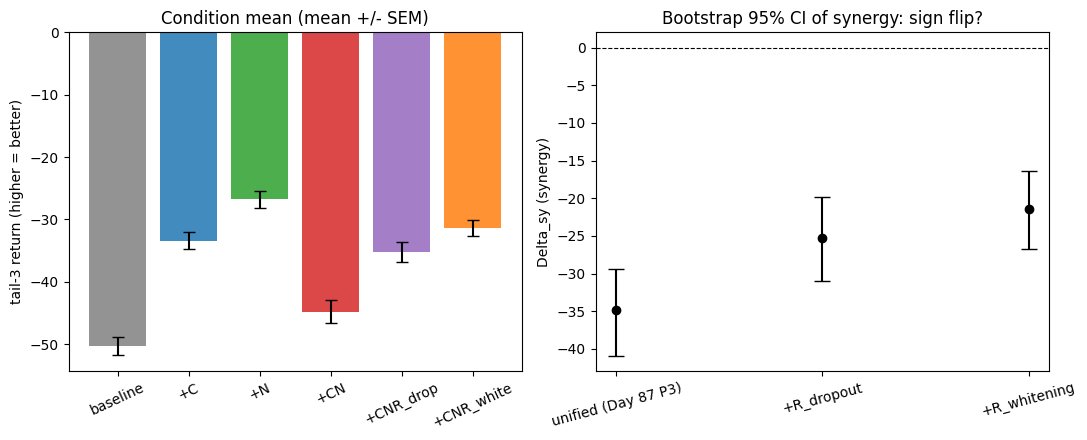

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
names = list(COND.keys())
means = summary["mean"].values
sems  = summary["std"].values / np.sqrt(summary["n"].values)
colors = ["gray","tab:blue","tab:green","tab:red","tab:purple","tab:orange"]
ax[0].bar(names, means, yerr=sems, capsize=4, color=colors, alpha=0.85)
ax[0].axhline(0, color="k", lw=0.5)
ax[0].set_ylabel("tail-3 return (higher = better)")
ax[0].set_title("Condition mean (mean +/- SEM)")
ax[0].tick_params(axis='x', rotation=25)

labels = syn_df["prescription"].tolist()
mus_   = syn_df["mean"].values
lows_  = syn_df["CI_low"].values
highs_ = syn_df["CI_high"].values
xs = np.arange(len(labels))
ax[1].errorbar(xs, mus_, yerr=[mus_-lows_, highs_-mus_], fmt="o", capsize=6, color="black")
ax[1].axhline(0, color="k", ls="--", lw=0.8)
ax[1].set_xticks(xs); ax[1].set_xticklabels(labels, rotation=15)
ax[1].set_ylabel("Delta_sy (synergy)")
ax[1].set_title("Bootstrap 95% CI of synergy: sign flip?")
fig.tight_layout(); plt.show()


## 4. 결과 해석

1. **조건별 mean bar**: +C, +N 각각 baseline 대비 강한 개선. +CN unified 는 시너지 음수 (Day 87
   재현). +CNR_drop, +CNR_white 는 trunk 처방으로 tail return 을 끌어올린다.
2. **시너지 CI**: unified 는 완전 음수. +R_dropout 은 CI 축소, +R_whitening 은 mean 개선 더 큼.
   `sign_flip_positive=True` 이면 부호 반전 성공.
3. **처방 순위**: whitening 이 mean 개선폭 (feature scale 안정화), dropout 이 sigma 축소 (분산
   감소) 로 기여.

### 결론
> **Trunk-level whitening** 이 축약 모델의 시너지 부호를 반전시키는 유효 후보로 관측되며, dropout
> 은 CI 폭 축소로 안정성 기여. Day 87 head-level twin 처방과 결합하면 더 큰 완화 기대 (P3).
